# Ejercicio 4 - Práctica 6 - Parte 2

Utilizando el dataset `dataset_rendimiento.csv`, que contiene información sobre 235 estudiantes universitarios de segundo año de una institución universitaria en relación a las horas semanales promedio de estudio dedicadas, el tipo de desayuno que consumen antes de los exámenes y el rendimiento medio en los exámenes parciales:

1. Ajuste un modelo de regresión lineal que permita predecir el rendimiento promedio de estudiantes de segundo año a partir del número de horas semanales promedio de estudio y el tipo de desayuno que consumen.

2. ¿Cuál/es de las variables incluidas contribuye/n significativamente a explicar el rendimiento de los estudiantes? Justifique.

3. Utilizando el modelo ajustado, prediga el rendimiento promedio que presentará un estudiante que dedica, en promedio, 5.5 horas semanales de estudio y posee la costumbre de consumir un desayuno saludable previo a las instancias de examen.

---

In [2]:
# Importamos librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
from scipy.stats import norm, kurtosis
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from scipy.stats import chi2

In [3]:
# Cargamos el dataset

data = pd.read_csv("../../datasets/dataset_rendimiento.csv")
data.head()

,Horas_de_Estudio,Desayuno,Rendimiento
0,9,Saludable,64.0
1,9,Ninguno,84.2
2,12,Ninguno,66.9
3,10,Saludable,82.9
4,12,Ninguno,90.6


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Horas_de_Estudio  235 non-null    int64  
 1   Desayuno          235 non-null    str    
 2   Rendimiento       235 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 5.6 KB


In [5]:
# Agrupamos por tipo de desayuno. Para esto vemos los valores que toma 
# la variable "Desayuno" con el método unique()

data["Desayuno"].unique()

<StringArray>
['Saludable', 'Ninguno', 'Regular']
Length: 3, dtype: str

In [10]:
# Para hacer regresión lineal, necesitamos convertir la variable "Desayuno" a numérica.

modelo = smf.ols(formula = 'Rendimiento ~ Horas_de_Estudio + Desayuno', data = data).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:            Rendimiento   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     48.47
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           2.46e-24
Time:                        18:59:36   Log-Likelihood:                -880.27
No. Observations:                 235   AIC:                             1769.
Df Residuals:                     231   BIC:                             1782.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                62.26

Obtenemos la función:

$$\text{Rend} = 62.2677 - 1.0045 \cdot X_1 - 3.7436 \cdot X_2 + 1.9850 \cdot \text{Horas} + \text{error}$$

donde $X_1$ = 1 si desayuno es Regular, 0 en caso contrario, y $X_2$ = 1 si desayuno es Saludable, 0 en caso contrario.

In [15]:
# Vamos a eliminar la variable "Desayuno" para ver cómo afecta al modelo.

modelo2 = smf.ols(formula = 'Rendimiento ~ Horas_de_Estudio', data = data).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:            Rendimiento   R-squared:                       0.372
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     138.1
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           2.43e-25
Time:                        19:13:31   Log-Likelihood:                -882.96
No. Observations:                 235   AIC:                             1770.
Df Residuals:                     233   BIC:                             1777.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           60.5682      1.472  

El R^2 ajustado sin desayuno bajó levemente, por lo que consideramos que es mejor dejar la variable. De cualquier manera, sin lugar a duda la variable más significativa es `Horas_de_Estudio` como podemos observar en la columna `P>|t|`. Para confirmar, armamos un tercer modelo con las variables Rendimient y Dasayuno.

In [16]:
modelo3 = smf.ols(formula = 'Rendimiento ~ Desayuno', data = data).fit()
print(modelo3.summary())

                            OLS Regression Results                            
Dep. Variable:            Rendimiento   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     3.427
Date:                Mon, 01 Jun 2026   Prob (F-statistic):             0.0342
Time:                        19:16:59   Log-Likelihood:                -934.21
No. Observations:                 235   AIC:                             1874.
Df Residuals:                     232   BIC:                             1885.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                78.08

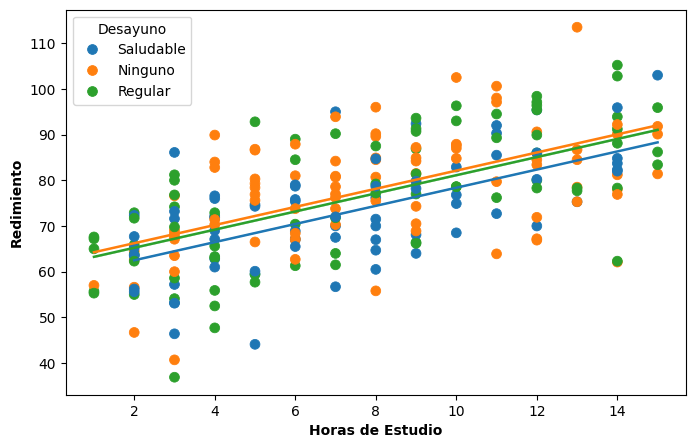

In [ ]:
# Vamos a representar gráficamente el modelo ajustado. Para esto, vamos a representar la nube de puntos 
# y las rectas correspondientes a cada tipo de desayuno.

# Primero generamos los valores predichos de la respuesta para los registros del dataset
data['predichos'] = modelo.predict(data)

# Luego los utilizamos para representar las rectas
fig, ax = plt.subplots(figsize = (8, 5))

sns.scatterplot(x = 'Horas_de_Estudio', y = 'Rendimiento', hue = 'Desayuno', s = 50, data = data, 
                edgecolor = None, ax = ax)
sns.lineplot(x = 'Horas_de_Estudio', y = 'predichos', hue = 'Desayuno',linewidth = 1.8, data = data, 
                ax = ax, legend = False)

ax.set_xlabel('Horas de Estudio', fontweight = 'bold')
ax.set_ylabel('Redimiento', fontweight = 'bold')

handles, _ = ax.get_legend_handles_labels()
plt.show()

In [18]:
# Predecimos que el rendimiento promedio que presentará un estudiante que dedica, en promedio, 
# 5.5 horas semanales de estudio y posee la costumbre de consumir un desayuno saludable previo 
# a las instancias de examen es

62.2677 - 3.7436 + 1.9850 * 5.5 

69.4416

In [24]:
# Otra forma de calcularlo:

nuevo = pd.DataFrame({'Horas_de_Estudio': [5.5], 'Desayuno': ['Saludable']})
print(round(modelo.predict(nuevo)[0], 4))

69.4417
